In [1]:
import os
import sys

os.chdir("/Users/karima/Ironhack-challenges/fake-news-nlp-classification")
sys.path.append(os.getcwd())

print(os.getcwd())

/Users/karima/Ironhack-challenges/fake-news-nlp-classification


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from src.data_loader import load_data, prepare_features_and_labels, split_data
from src.preprocessing import preprocess_data
from src.feature_extraction import create_bow_features
from src.evaluator import evaluate_model, save_confusion_matrix, save_metrics_plot
from src.experiment_tracker import save_experiment_result
from src.model_manager import save_model, save_vectorizer
from src.config import MODELS_DIR

In [3]:
# Class constants
MODEL_ID = "exp_01"
MODEL_NAME = "Baseline Logistic Regression + BoW"
MODEL_PATH = MODELS_DIR / "bow_logistic_regression.pkl"

In [4]:
# Load the dataset
data = load_data()

In [5]:
# Extract features X and labels y
X, y = prepare_features_and_labels(data)

In [6]:
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = split_data(X, y)

In [7]:
# data cleaning, tokenizationa and lemmatization
X_train_clean = preprocess_data(X_train)
X_test_clean = preprocess_data(X_test)

In [8]:
# # 5. Create Bag of Words features
X_train_bow, X_test_bow, bow_vectorizer = create_bow_features(
    X_train_clean,
    X_test_clean
)

In [9]:
# Train the model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_bow, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [10]:
# evaluate the model
metrics, predictions = evaluate_model(
    model,
    X_test_bow,
    y_test
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3989
           1       1.00      0.99      0.99      4000

    accuracy                           0.99      7989
   macro avg       0.99      0.99      0.99      7989
weighted avg       0.99      0.99      0.99      7989



In [14]:
# Save the model and the vectorizer
model_path = save_model(
    model,
    "bow_logistic_regression.pkl"
)

vectorizer_path = save_vectorizer(
    bow_vectorizer,
    "bow_vectorizer.pkl"
)

TypeError: join() got an unexpected keyword argument 'exist_ok'

In [ ]:
# Save and show metrics plot
metrics_plot_path = save_metrics_plot(
    metrics,
    "exp_01_baseline_logigstic_bow_regression"
)

NameError: name 'save_metrics_plot' is not defined

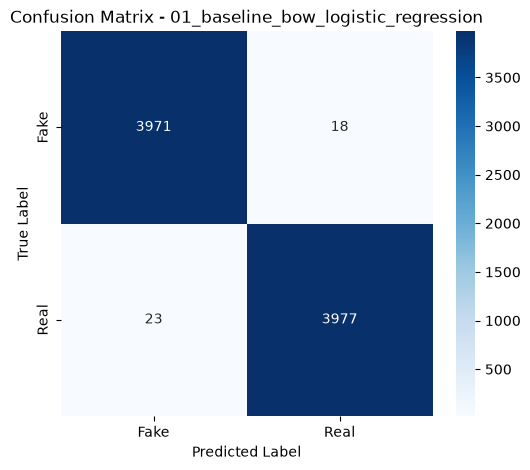

In [ ]:
# Save and show confusion matrix
confusion_matrix_path = save_confusion_matrix(
    y_test,
    predictions,
    "01_baseline_bow_logistic_regression"
)

In [ ]:
# Train accuracy
train_prediction = model.predict(X_train_bow)

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

In [ ]:
# Save experiment result
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "features": "Bag of Words",
    "preprocessing": "Lowercase + HTML removal + stopword removal + lemmatization",
    "algorithm": "Logistic Regression",
    "train_accuracy": train_accuracy,
    "test_accuracy": metrics["test_accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "notes": "Baseline Logigstic Bow Regresssioon model.",
    "model_path": MODEL_PATH
}

tracking = save_experiment_result(**experiment)

tracking.tail()

,model_id,model_name,features,preprocessing,algorithm,train_accuracy,test_accuracy,precision,recall,f1_score,notes,model_path
0,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
1,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
